# Homework 1: Building our First Neuron with PyTorch

### Overview

This notebook is designed to guide you through the concepts of dot product multiplication, machine learning pipeline, data loaders, and model parameter estimation with Gradient Descent.


### Learning Objectives:

- Practice with PyTorch fundamental tools and data structures.
- Setting up your modeling pipeline.
- Implement Gradient Descent with different learning rates.
- Train and test a logisitc regressor neuron for tabulated and image data
- Compare from scratch and PyTorch implementation


### Structure

**Part 1: PyTorch Practice**
- 1.1. Dot product
- 1.2. Autograd
- 1.3. Custom Datasets
- 1.4. Dataloaders and Transforms

**Part 2: From Scratch ML Pipeline**
- 2.1. Gradient Descent
- 2.2. Logistic Regression Neuron
- 2.3. Training Model
- 2.4. Testing Model
- 2.5. Questions


### Instructions
- Complete the exercises
  - Fill in the sections with  
  ```python
      ##### YOUR CODE STARTS HERE #####

      ##### YOUR CODE ENDS HERE #####
  ```
  - Do not change other variables in the notebook
- Answer the Questions in areas `2.5`, and `3.3`
- Read through each section carefully to understand the concepts behind the implementations.
- Run all code cells to see plots and results.
- Ask for help if needed, but avoid code sharing.
- Utilize online resources responsibly.
- Ensure you have necessary libraries installed (sklearn, PyTorch, matplotlib).


### Getting Help

- If you encounter issues or need assistance, here is the preferred approach to finding help:

    1. **Self-Reflection**: Sometimes we go to other sources too quickly. Make sure that you had spent at least 1 hour thinking and resolving an issue prior to seeking the help of the internet or others.
    
    2. **Search Online**: Begin by using online resources, inlcuding libraries documentation, forums, and blogs, to find insights on your strugles. Make sure to solve problems on your own as much as possible without directly copying code.
   
    3. **Consult Peers or GenAI**: Reach out to fellow students or GenAI for guidance. Discord is a great tool to connect with others. Please remember that sharing actual code or problem answers is prohibited.
   
    4. **Contact the TA**: If your issue still persists after exploring the above steps, reach out to the Teaching Assistant (TA).
   
    5. **Instructor Assistance**: If you still require help and the TA has not been able to resolve your issue, you should contact the instructor.

- You are welcome to go straigh to the TAs or Instructor. However, we believe learning to properly escalate issues will serve you well in the future.


### Tutorials and Documentation Links For Help

**Here are the links to the tutorials:**

- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- [Pandas Tutorials](https://github.com/CuriousNeuralNerd/Tutorials/blob/fbdeb171ed16958e7571df0f1272c68ce3f4d3ab/pandas_basics.ipynb)
- [Matplotlib Tutorials](https://github.com/CuriousNeuralNerd/Tutorials/blob/fbdeb171ed16958e7571df0f1272c68ce3f4d3ab/matplotlib_basics.ipynb)
- [scikit-learn Tutorials](https://github.com/CuriousNeuralNerd/Tutorials/blob/fbdeb171ed16958e7571df0f1272c68ce3f4d3ab/scikit_learn_basics.ipynb)


**Here are the links to the official documentation for the libraries:**

- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [NumPy Documentation](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [pandas Documentation](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)
- [Matplotlib Documentation](https://matplotlib.org/stable/users/explain/quick_start.html)
- [scikit-learn Documentation](https://scikit-learn.org/stable/)

### **Grading Rubric**
  
| **Part** |    **Description**            | **Weight** |
|----------|-------------------------------|------------|
| 1        |    PyTorch Practice           | **40%**    |
| 2        |    From Scratch Neuron        | **60%**    | |

Good design practices considered in grading:
- Modularized code. Functions and classes used appropriately.
- Check function arguments for correct types and structure.
- Vectorize code when possible (e.g., avoid for loops for vector operations.)

## Submission Instructions

To complete your submission for this homework, please follow these steps:

1. **Save the Completed Notebook**: Ensure that all your code, plots, images, and written answers are finalized, then save the `.ipynb` file.
2. **Export to PDF**: Additionally, export or save your completed notebook as a `PDF` file. Confirm the PDF shows the latest and greatest results.
3. **Submit in CANVAS**: Upload to Canvas both the `.ipynb` file and the `PDF` file. Make sure that both files are clearly labeled and include your Net ID (`HW_x_NetID`).

## Libraries

Please make sure that the cell below runs without problems prior to proceeding with the exercises.

In [ ]:
import torch
import torchvision.utils as tv_utils
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

## 1. PyTorch Practice

### 1.1 Dot Product

![Dot Product: Piece by Piece](https://betterexplained.com/wp-content/webp-express/webp-images/uploads/dotproduct/dot_product_components.png.webp)

#### Understanding the Dot Product in Machine Learning

$$
\mathbf{a} \cdot \mathbf{b} = a_x \cdot b_x + a_y \cdot b_y = ||\mathbf{a}|| ||\mathbf{b}|| \cos(\theta)
$$
where
- $\mathbf{a}$ and $\mathbf{b}$ are vectors.
- $a_x$ and $b_x$ are the x-axis component of the vectors.
- $a_y$ and $b_y$ are the y-axis component of the vectors.
- $||\mathbf{a}||$ and $||\mathbf{b}||$ are their magnitudes (lengths).
- $\theta$ is the angle between them.

The dot product (or matrix multiplication) is a fundamental operation in deep learning and machine learning. It provides an efficient way to compare numerical representations of two pieces of information.

Read [this blog](https://betterexplained.com/articles/vector-calculus-understanding-the-dot-product) to capture the escence of the dot product operation.

##### **Intuition Behind the Dot Product**
You can think of the dot product as a form of directional multiplication:
- If two vectors have similar directions, the dot product produces a large value relative to their magnitudes.
- If the vectors are very different in direction (e.g., orthogonal to each other), the dot product yields a value close to zero.

This concept is reinforced by the second equation showing a direct relationship between the dot product and the angle between two vectors:
- When $\theta = 0^\circ$ (aligned vectors), $\cos(\theta) = 1$, resulting in a large positive dot product.
- When $\theta = 90^\circ$ (orthogonal vectors), $\cos(\theta) = 0$, and the dot product is zero.
- When $\theta = 180^\circ$ (opposite directions), $\cos(\theta) = -1$, leading to a large negative dot product.

The dot product is the basis to one of the most popular similarity metrics in Machine Learning; the **Cosine Similarity** computed by normalizing the dot product with the magnitudes of the vectors.
$$
\text{Cosine Similarity} = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| ||\mathbf{b}||}
$$
This removes the influence of vector lengths and focuses solely on the direction, making it a useful metric in many applications:
- Text similarity: Comparing document embeddings.
- Feature matching: Identifying similar patterns in high-dimensional data.

This concept extends naturally to matrices, which can be seen as collections of vectors. Thus, the dot product can be applied to measure similarities in more complex structures.

##### **Key Takeaway**
The dot product is a quick and efficient similarity measure:
- **Larger dot product values** (relative to the magnitudes of the original vectors) indicate greater similarity.
- **Smaller dot product values** suggest dissimilarity.

##### **Task**
In this exercise, you will use the dot product to determine which samples in ```X``` are more relevant or similar to the model parameters ```w```. Note that your are not using the Cosine Similarity metric.

You are receiving a stream of data from a sensor. The sensor camptures 5 samples per transmitted package and collects three features per sample. The samples arrive in sequence. E.g., $[x^{(0)}_1, x^{(0)}_2, x^{(0)}_3, x^{(1)}_1,...x^{(5)}_3]$, where the superscript is the sample index and the subscript is the feature index.

After you are finished with the task, observe and draw insights on the relationship between the samples feature values, the model weights, and the relevance scores.

In [ ]:
# Stream of data
data_package = [0.2, 0.8, 0.5, 0.9, 0.1, 0.4, 0.3, 0.7, 0.2, 0.6, 0.2, 0.8, 0.5, 0.4, 0.3]

# Model weight vector
w = torch.tensor([0.6, 0.3, 0.1], dtype=torch.float32)

In [ ]:
X = torch.reshape(torch.tensor(data_package), (-1, 3))
X

tensor([[0.2000, 0.8000, 0.5000],
        [0.9000, 0.1000, 0.4000],
        [0.3000, 0.7000, 0.2000],
        [0.6000, 0.2000, 0.8000],
        [0.5000, 0.4000, 0.3000]])

In [ ]:
##### YOUR CODE STARTS HERE #####

# Convert data to a float32 tensor matrix where the samples are in each row and
# the features are in each column.
feature_dim = 3
X = torch.reshape(torch.tensor(data_package, dtype=torch.float32), (-1, feature_dim))


# Compute the similarity or relevance scores between the data samples and the
# model parameters
relevance_scores = torch.matmul(X, w.view(feature_dim, 1))

# Rank items by relevance scores
# HINT: Use torch.argsort
sorted_indices = torch.argsort(relevance_scores, dim=0)
ranked_scores = relevance_scores[sorted_indices]
ranked_features = X[sorted_indices]

##### YOUR CODE ENDS HERE #####

# Output
print("Data matrix:")
print(X)
print("\nRanked Items:")
for i, (features, score) in enumerate(zip(ranked_features, ranked_scores)):
    print(f"Rank {i + 1}; Sample {sorted_indices[i]}: Features = {features.numpy()}, Score = {score.item()}")


Data matrix:
tensor([[0.2000, 0.8000, 0.5000],
        [0.9000, 0.1000, 0.4000],
        [0.3000, 0.7000, 0.2000],
        [0.6000, 0.2000, 0.8000],
        [0.5000, 0.4000, 0.3000]])

Ranked Items:
Rank 1; Sample tensor([0]): Features = [[0.2 0.8 0.5]], Score = 0.4100000262260437
Rank 2; Sample tensor([2]): Features = [[0.3 0.7 0.2]], Score = 0.4100000262260437
Rank 3; Sample tensor([4]): Features = [[0.5 0.4 0.3]], Score = 0.45000001788139343
Rank 4; Sample tensor([3]): Features = [[0.6 0.2 0.8]], Score = 0.5
Rank 5; Sample tensor([1]): Features = [[0.9 0.1 0.4]], Score = 0.6100000739097595


### 1.2 Autograd

In this exercise, you will play with PyTroch autograd. You will mannually compute the gradients and compare your results with autograd.

Functions for this exercise:
- $c = 3a^3 + b^5$
- $y = 2c + 2d^2$

Use the chain rule and autograd to compute $\frac{\partial y}{\partial a}$, when ```a=[2, 5], b=[9,1], d=[-2,3]```.

In [ ]:
# Create a function to manually compute dy/da
# Your code is the result of using the chain rule on y.
def manual_da_gradient(a, b, c, d):
    ##### YOUR CODE STARTS HERE #####
    da = 18* (a**2)

    ##### YOUR CODE ENDS HERE #####
    return da

##### YOUR CODE S HERE #####

In [ ]:
##### YOUR CODE STARTS HERE #####

# Create tensors for variables a, b, and d
a = torch.tensor([2, 5], dtype=torch.float32, requires_grad=True)
b = torch.tensor([9, 1], dtype=torch.float32, requires_grad=True)
d = torch.tensor([-2, 3], dtype=torch.float32, requires_grad=True)

# Compute tensors c and y
c = 3*(a**3) + b**5
y = 2*c + 2*(d**2)
dy = torch.ones_like(y)

# Compute the gradients of all parameters w.r.t y
# HINT: use the tensor .backward function
y.backward(gradient=dy)


# Print the gradients
print("Gradients:")


##### YOUR CODE ENDS HERE #####


# Is your theoretical dy/da the same as PyTorch dy/da?
# Compute manual gradient dy/da
manual_da = manual_da_gradient(a, b, c, d)
print(f"\nDo theory and Autograd match? => {torch.isclose(manual_da, a.grad)}")

Gradients:

Do theory and Autograd match? => tensor([True, True])


### 1.3. Datasets, Transforms and Dataloaders
In this exercise, you will download an OpenML dataset. We will focus on the MNIST dataset. Note that PyTorch already offers this library, but we will use a more complex path to practice how to generate our own custom datasets. In addition, you will create a transform to prepare the data for model training and a dataloader to sample the dataset.

Check PyTorch [Datasets and Dataloaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) and [Transforms](https://pytorch.org/tutorials/beginner/basics/transforms_tutorial.html) turorials for more information on this task.


### 1.3.1 Transforms

In [ ]:
class Normalize01(object):
    """Normalize image in the range of [0,1].

    Args:
        None.
    """

    def __init__(self):
      pass

    def __call__(self, image):
        """
        Args:
            image (numpy.ndarray): Image to be normalized.

        Returns:
            numpy.ndarray: Normalized image.
        """

        ##### YOUR CODE STARTS HERE #####

        # check for a valid image array
        h = np.sqrt(len(image))
        assert h*h==len(image), 'Not a valid image'
        # we can have other checks here, like number of dimensions 2,
        #assert len(image.shape) == 2, 'Inputs must be two dimensional arrays'
        # integer values in the range of 1 and 255, etc.

        # normalize between zero and 1
        norm_img = (image-torch.min(image))/(torch.max(image) - torch.min(image))
        ##### YOUR CODE ENDS HERE #####

        # return normalized sample and label
        return norm_img

class ToTensor(object):
    """ Convert ndarrays in sample to Tensors.
    """

    def __init__(self):
      pass

    def __call__(self, image):
      """
      Args:
          image (numpy.ndarray): Array to be converted to tensor.

      Returns:
          Tensor: Converted image.
      """

      ##### YOUR CODE STARTS HERE #####

      # Convert to Tensor
      image = torch.from_numpy(image)

      ##### YOUR CODE ENDS HERE #####

      return image


# Create composite transform object
# HINT: Use transforms.Compose function.

##### YOUR CODE STARTS HERE #####

feature_transform = transforms.Compose([ToTensor(), Normalize01()])

target_transform = None#transforms.Compose([ToTensor()])

##### YOUR CODE ENDS HERE #####


### 1.3.2 Dataset
In this exercise, you will download a custom dataset, and place it in a PyTorch Dataset object.

Task steps:
1. Download the OpenML mnist_784 dataset ([link](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv?resource=download)) hosted by Kggle in the csv format. Note that you have two files: one for the training set and another for the test set.
2. You will use Pandas library to load the dataset to memory.
3. Display data to learn the indexes for labels and features
4. Use Numpy slicing to sperate data and labels.
5. Keep data for zero and one digit images.


**Initial loading and display of dataset**

In [ ]:
!pip install opendatasets

In [ ]:
##### YOUR CODE STARTS HERE #####
# Download dataset
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/oddrationale/mnist-in-csv?resource=download")
# {"username":"sounak766","key":"528530c50ce4ade9ebfbf9214c797a02"}
# Load dataset
data = pd.read_csv('/content/mnist-in-csv/mnist_train.csv')

# Display dataset
# HINT: Use display function instead of print.
display(data)

##### YOUR CODE ENDS HERE #####'''

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sounak766
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv


100%|██████████| 15.2M/15.2M [00:00<00:00, 65.6MB/s]


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Build data loading function**

In [ ]:

def load_mnist_from_kaggle(filepath):
    """
    Load the MNIST dataset from a local Kaggle CSV file.

    Args:
        filepath (str): Path to the CSV file.

    Returns:
        tuple: (features, labels), where features is the feature matrix (images) and labels is the
        target vector.
    """

    ##### YOUR CODE STARTS HERE #####

    # Load CSV file
    data = pd.read_csv(filepath)

    # Separate features and labels
    labels = np.array(data['label'])
    features = np.array(data.drop('label', axis = 1))

    # Keep zeros and ones
    mask = np.add(labels == 0, labels == 1)
    features = features[mask]
    labels = labels[mask].astype(int)

    # Ensure labels are integers (ARFF may load them as bytes)

    ##### YOUR CODE ENDS HERE #####

    return features, labels

'''# Test working
X, y = load_mnist_from_kaggle('/content/mnist-in-csv/mnist_train.csv')
import matplotlib.pyplot as plt
plt.imshow(np.reshape(X[324, :], (28,28)))'''

"# Test working\nX, y = load_mnist_from_kaggle('/content/mnist-in-csv/mnist_train.csv')\nimport matplotlib.pyplot as plt\nplt.imshow(np.reshape(X[324, :], (28,28)))"

In this step, you will generate a Dataset object for the MNIST dataset.

Number of samples in MNIST Dataset: 12665.
Each sample has 784 features.
Number of samples in MNIST Dataset: 2115.
Each sample has 784 features.


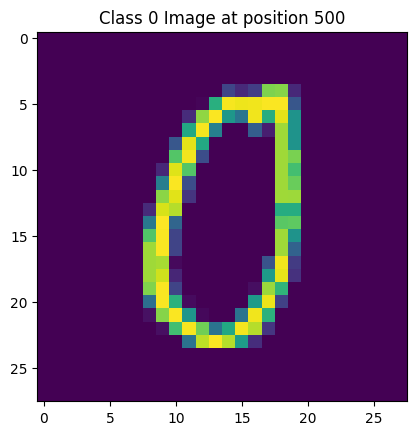

In [ ]:
class MNISTDataset(Dataset):

##### YOUR CODE STARTS HERE #####
    def __init__(self, data_file_path, transform=feature_transform, target_transform=target_transform):
        """
        Generate PyTorch Dataset object from MNIST dataset in ARFF format.

        Args:
            data_file_path (str): Path to the ARFF file.
            transform (OBJ): transform operations on features
            target_transform (OBJ): transform operations on labels
        """
        # Get features and labels from dataset
        # HINT: load_mnist_from_kaggle
        self.features, self.labels = load_mnist_from_kaggle(data_file_path)

        # Store transforms
        self.transform = transform
        self.target_transform = target_transform

        # print dataset number of samples and features
        print(f"Number of samples in MNIST Dataset: {len(self.labels)}.")
        print (f"Each sample has {self.features.shape[1]} features.")


    def __len__(self):
        """
            Returns the size of the dataset.
        """
        # number of samples
        no_samples = len(self.labels)

        return no_samples

    def __getitem__(self, idx):
        """
            Select data sample at index idx and apply correspoinding transformations.

            Args:
            idx (int): Index of image.

            Returns:
            dict: {'image': image, 'label': label}
        """
        # get sample
        image = self.features[idx]
        label = self.labels[idx]

        # Apply feature transformations
        if(self.transform):
            image = self.transform(image)

        # Apply label transformations
        if(self.target_transform):
            label = self.target_transform(label)

        return image, label

    def show_image_sample(self, idx):
        """
            Show image sample at index idx.

            Args:
            idx (int): Index of image.
        """
        # get sample at position idx and reshape to MNIST image dimensions
        # HINT: MNIST images are squared images.
        image = self.features[idx].reshape(28, 28)

        # use matplotlib library to display the image
        plt.imshow(image)
        plt.title(f"Class {self.labels[idx]} Image at position {idx}")
        plt.show()

##### YOUR CODE ENDS HERE #####


##############################################################
# Generate MNIST Train Dataset object
filepath = '/content/mnist-in-csv/mnist_train.csv' #"/content/drive/My Drive/Colab-Notebooks/Spring2025-COSC525/datasets/mnist/mnist_train.csv"
train_dataset = MNISTDataset(filepath, feature_transform, target_transform)

# Generate MNIST Test Dataset object
filepath = '/content/mnist-in-csv/mnist_test.csv' #"/content/drive/My Drive/Colab-Notebooks/Spring2025-COSC525/datasets/mnist/mnist_test.csv"
test_dataset = MNISTDataset(filepath, feature_transform, target_transform)

# Show image of train sample 500
train_dataset.show_image_sample(500)


### 1.3.2 Dataloaders

torch.Size([5, 784]) torch.Size([5])


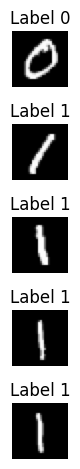

In [ ]:
##### YOUR CODE STARTS HERE #####
def display_images(image_batch, labels):
    """
    Displays images from a matrix of flattened 28x28 images.

    Args:
        image_batch (numpy.ndarray): A (N, M) matrix where each row is a flattened square image.
    """

    # Compute number of samples
    n = image_batch.shape[0]

    # Compute size of square images
    m = image_batch.shape[1]
    image_size = int(np.sqrt(m))


    if n==1:
        image = np.reshape(image_batch, (image_size, image_size))  # Reshape to image_sizeximage_size
        plt.imshow(image, cmap='gray')      # Display image in grayscale
        plt.axis('off')                     # Turn off axis labels
        plt.title(f"Label {labels}")       # Optional title for each image
        plt.show()
    else:
      # Reshape each row back to image_size*image_size and plot
      fig, axes = plt.subplots(nrows = n)  # Create a row of n subplots
      for i, ax in enumerate(axes):
          image =  np.reshape(image_batch[i], (image_size, image_size)) # Reshape to image_sizeximage_size
          ax.imshow(image, cmap='gray')      # Display image in grayscale
          ax.axis('off')                     # Turn off axis labels
          ax.set_title(f"Label {labels[i]}")       # Optional title for each image

      plt.tight_layout()
      plt.show()

###########################
# Test a DataLoader with training dataset and batch size of 5
batch_size =5
dataloader = DataLoader(train_dataset, batch_size=5)


# Test data loader
# Get iterable object
dataiter = iter(dataloader)
# Sample batch
images, labels = next(dataiter)

print(images.shape, labels.shape)

# show images
display_images(images, labels)

# Create Train and Test dataloaders of batch size of the size of the dataset
train_dataloader = DataLoader(train_dataset, batch_size = len(train_dataset))
test_dataloader  = DataLoader(test_dataset,  batch_size = len(test_dataset))

##### YOUR CODE ENDS HERE #####

## 2. Building a Perceptron Neuron from Scratch

**What is a Neuron?**

A neuron is the fundamental unit of neural networks. It takes multiple inputs, applies weights to them, sums them up, and uses an activation function to produce an output. This process is mathematically represented as:

$$
a = \sigma(\sum_{i=1}^{n} w_i x_i + b)
$$

- $(a)$: output of model in logits
- $(x_i)$: Inputs
- $(w_i)$: Weights
- $(b)$: Bias term
- $(\sigma)$: Activation function (e.g., sigmoid)

Below is a visual representation of a neuron:

![Artificial Neuron](https://rasbt.github.io/mlxtend/user_guide/classifier/Adaline_files/adaline_schematic.png)

We will build these components in the next tasks.


### 2.1 - Activation Function Block: Sigmoid function

Build a function that returns the sigmoid of a numpy real vector or matrix $x$.

**Reminder**:
$sigmoid(x) = \frac{1}{1+e^{-x}}$

This function is also known as the logistic function. It is a non-linear function used not only in Machine Learning (Logistic Regression), but also in Deep Learning.

In [ ]:
def sigmoid(x):
    """
    Compute sigmoid of x.

    Arguments:
    x -- A scalar or numpy vector or matrix

    Return:
    s -- sigmoid(x)
    """

    # YOUR CODE STARTS HERE
    s = 1/(1 + torch.exp(-1*x))

    # YOUR CODE ENDS HERE

    return s

##### TEST  #####
a = torch.tensor([1])

print(f"sigmoid([1]) = {sigmoid(a)}")

if(torch.isclose(sigmoid(a), torch.tensor([0.7310585786300049]))):
    print("Test passed")

sigmoid([1]) = tensor([0.7311])
Test passed


### 2.2- Build Sigmoid Gradient
Computing gradients is an important step in backpropagation. In this exercise, you will compute the gradient (i.e., derivative) of the sigmoid function.

**Recall**
$$sigmoid\_derivative(x) = \sigma'(x) = \sigma(x) (1 - \sigma(x))\tag{2}$$

In [ ]:
def sigmoid_gradient(x):
    """
    Compute the gradient (also called the slope or derivative) of the sigmoid function with respect to its input x.

    Arguments:
    x -- A scalar or numpy array

    Return:
    ds -- Your computed gradient.
    """

    # YOUR CODE STARTS HERE
    ds = torch.mul(sigmoid(x), (1-sigmoid(x)))

    # YOUR CODE ENDS HERE

    return ds

##### TEST  #####
a = torch.tensor([1, 2, 3])
print(f"sigmoid_gradient(a) = {sigmoid_gradient(a)}")

print(f"Test passed: {torch.isclose(sigmoid_gradient(a), torch.tensor([0.19661193, 0.10499359, 0.04517666]))}")

sigmoid_gradient(a) = tensor([0.1966, 0.1050, 0.0452])
Test passed: tensor([True, True, True])


### 2.3 Error Block: Implement Cross Entropy Loss

The cost/loss function is used to evaluate the performance of your model. The bigger your loss is, the more different your predictions ($ \hat{y} $) are from the true values ($y$). In deep learning, you use optimization algorithms like Gradient Descent to train your model and to minimize the cost.

$LogLoss(y, a) = - (y \cdot log(a) + (1-y) \cdot log(1-a))$

You will implement vectorized version of the Cross Entropy or Log loss. The function will receive the samples targets and model predictions.



In [ ]:
def CrossEntropy(A, Y):
    """
    Computes the LogLoss/Cross-Entropy cost.

    Arguments:
    A -- The sigmoid output of the output layer with shape (N, 1)
    Y -- "true" labels vector of shape (N, 1)

    Returns:
    cost -- cross-entropy cost as discussed in class
    """

    ####################################
    # YOUR CODE STARTS HERE

    m =  A.shape[0] #if len(A.shape) == 2 else len(A) # number of examples

    # Manage NaNs in the logs
    # HINT: torch.clamp
    epsilon = 1e-6
    A = torch.clamp(A, min = epsilon, max = 1)

    # compute LogLoss cost
    cost = -1 * torch.mean(torch.mul(Y.view(-1, 1), torch.log(A).view(-1, 1)) + torch.mul((1 - Y).view(-1, 1), torch.log(1 - A).view(-1, 1)))


    # check that we don't have nans otherwise stop
    assert not(torch.isnan(cost).any())

    # YOUR CODE ENDS HERE
    ####################################

    cost = float(torch.squeeze(cost))  # makes sure cost is the dimension we expect.
                                    # E.g., turns [[17]] into 17

    return cost


# Testing
A = torch.tensor( [[0.999, 0.5, 0.001]]).T
Y = torch.tensor( [[0.0, 0.0, 0.0]]).T
print(f"Test passed: Computed {CrossEntropy(A, Y)}, Answer {2.5339720249176025}")

Test passed: Computed 2.5339720249176025, Answer 2.5339720249176025


### 2.4 Model Parameters: Initialize parameters function
Implement parameter initialization in the cell below. You have to initialize w as a vector of zeros.

In [ ]:
def initialize_params(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.

    Argument:
    dim -- size of the w vector we want (or number of weight parameters in this case)

    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias) of type float
    """

    # (≈ 2 lines of code)

    # YOUR CODE STARTS HERE
    w = torch.zeros(dim, 1)
    b = 0.

    # YOUR CODE ENDS HERE

    return w, b

dim = 2
w, b = initialize_params(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

if((w==torch.tensor([0., 0.])).all()):
    print("Test passed")

w = tensor([[0.],
        [0.]])
b = 0.0
Test passed


### 2.5 Forward propagation

You will build the forward propagation routine for your neuron that will propagate the inputs to the output of the neuron (i.e., produce a prediction).

Implement a function `model()` that computes a prediction.

**Hints**:

Forward Propagation:
- Input X, w, and b. The parameters w and b initialized with some arbitrary vector or number (e.g., vector of zeros or a zero).
- You compute $A = \sigma(X \cdot w + b)$
- Use a sigmoid activation function.

In [ ]:
def model(X, W, b):
    """
    Makes a prediction based on inputs and parameters.

    Arguments:
    X -- input data of size (N, M), where N is the number of samples and M is the number of features.
    W -- weights vector of size (M, 1)
    b -- bias scalar

    Returns:
    A -- Output of activation function
    """

    # YOUR CODE STARTS HERE
    A = sigmoid(torch.matmul(X, W) + b)
    # YOUR CODE ENDS HERE

    return A

### 2.6 Backward propagation

You will build the routines to compute the cost and gradients to update the parameters.

Implement a function `cost_and_backprop()` that computes the cost function and its gradient to the parameters.

**Hints**:

Cost and backward Propagation:
- You calculate the cost function: $J = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)}))$

Here are the two formulas you will be using:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X \cdot (A-Y)\tag{7}$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{8}$$

In [ ]:
def cost_and_backprop(X, Y, A):
    """
    Computes the cost function and its gradient for the model's parameters.

    Arguments:
    X -- input data of size (N, M), where N is the number of samples and M is the number of features.
    Y -- true "label" vector of size (N, 1)
    A -- Output of activation function (Hint: Model output)

    Returns:
    cost -- cross-entropy cost
    dW -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b
    """

    # YOUR CODE STARTS HERE

    # Compute cost
    cost = CrossEntropy(A, Y)


    # Compute gradients
    # Number of features
    m = len(Y)

    # Compute dZ
    #dZ =
    #Compute dW
    dW = torch.matmul(X.T, (A-Y))/m
    #Compute db
    db = torch.sum(A-Y)/m

    # YOUR CODE ENDS HERE

    return cost, dW, db

# Test the function
X = torch.rand(10,5)
Y = torch.ones(10, 1)
A = torch.zeros(10,1)
#print(X.shape, Y.shape, A.shape)
print(cost_and_backprop(X,Y,A))

(13.815511703491211, tensor([[-0.4704],
        [-0.6484],
        [-0.6314],
        [-0.5770],
        [-0.5230]]), tensor(-1.))


In [ ]:
# Propagate, Cost, and Backprop tests

w = torch.tensor([[1.], [2]])
b = 1.5
X = torch.tensor([[1., 3.],[-2.,0.5],[-1.,-3.2]])
Y = torch.tensor([[1], [1], [0]], dtype=torch.float32)

print(X.shape)
print(Y.shape)

# Predict
A = model(X, w, b)
print(A)

# Cost and backprop
cost, dW, db = cost_and_backprop(X, Y, A)

assert dW.shape == (2, 1)


print ("dw = " + str(dW))
print ("db = " + str(db))
print ("cost = " + str(cost))

print(f"cost test passed: {np.isclose(cost,0.15901, atol=0.00001)}")
print(f"dW test passed: {torch.isclose(dW, torch.tensor([[0.25072],[-0.06604]]), atol=0.00001)}")
print(f"db test passed: {torch.isclose(db, torch.tensor(-0.125), atol=0.00001)}")

torch.Size([3, 2])
torch.Size([3, 1])
tensor([[0.9998],
        [0.6225],
        [0.0027]])
dw = tensor([[ 0.2507],
        [-0.0660]])
db = tensor(-0.1250)
cost = 0.15900537371635437
cost test passed: True
dW test passed: tensor([[True],
        [True]])
db test passed: True


### 2.7 - Optimization
- You have initialized your parameters.
- You are also able to compute a cost function and its gradient.
- Now, you want to update the parameters using gradient descent.

Write down the optimization function. The goal is to learn $w$ and $b$ by minimizing the cost function $J$. For a parameter $\theta$, the update rule is $ \theta = \theta - \alpha \text{ } d\theta$, where $\alpha$ is the learning rate.

In [ ]:
from tqdm import tqdm

def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 1, 1)
    b -- bias, a scalar
    X -- data of shape (num_px * num_px * 1, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps

    Returns:
    w and b -- weights w and bias b
    dw and db -- gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.

    Tips:
    You basically need to write down two steps and iterate through them:
        1) Calculate the cost and the gradient for the current parameters. Use propagate().
        2) Update the parameters using gradient descent rule for w and b.
    """

    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []

    for i in tqdm(range(num_iterations)):


        # YOUR CODE STARTS HERE
        # Forward propagatation
        A = model(X, w, b)

        # YOUR CODE ENDS HERE

        # Cost and gradient calculation
        # cost, dw, db = ...
        # YOUR CODE STARTS HERE

        cost, dw, db = cost_and_backprop(X, Y, A)

        # YOUR CODE ENDS HERE

        # update rule
        # w = ...
        # b = ...
        # YOUR CODE STARTS HERE
        w -= learning_rate * dw
        b -= learning_rate * db

        # YOUR CODE ENDS HERE

        # Record the costs
        if i % 10 == 0:
            costs.append(cost)

            # Print the cost every 10 training iterations
            if print_cost:
                print ("Cost after iteration %i: %f" %(i, cost))

    return costs, w, b, dw, db

In [ ]:
###########################
# DO NOT CHANGE

w =  torch.tensor([[1.], [2]])
b = 1.5
X = torch.tensor([[1., -2., -1.], [3., 0.5, -3.2]]).T
Y = torch.tensor([[1., 1., 0.]]).T
costs, w, b, dw, db = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print ("w = " + str(w))
print ("b = " + str(b))
print ("dw = " + str(dw))
print ("db = " + str(db))
print("Costs = " + str(costs))

#checking first element of each variable only
if ((np.round(w[0].item(),5)==0.80956) and
    (np.round(b.item(),5)==1.59487) and
    (np.round(dw[0].item(),6)==0.178605) and
    (np.round(db.item(),5)==-0.08888) and
    (np.round(costs[0],4)==0.1590)):
    print("Test passed.")

# DO NOT CHANGE
###########################

100%|██████████| 100/100 [00:00<00:00, 4321.44it/s]

w = tensor([[0.8096],
        [2.0508]])
b = tensor(1.5949)
dw = tensor([[ 0.1786],
        [-0.0484]])
db = tensor(-0.0889)
Costs = [0.15900537371635437, 0.15180473029613495, 0.14511175453662872, 0.1388835459947586, 0.13308079540729523, 0.12766779959201813, 0.1226121112704277, 0.11788424104452133, 0.1134573444724083, 0.10930710285902023]
Test passed.


### 2.8 Predict
The **optimize** function will output the learned w and b. We are able to use w and b to predict the labels for a dataset X.

**Implement the `predict()`

There are two steps to computing predictions:

1. Calculate $A = \sigma(w^T X + b)$

2. Compute $\hat{Y}$ by onverting the entries of $A$ into 0 (if activation < 0.5) or 1 (if activation >= 0.5), stores the predictions in a vector `Y_prediction`.

In [ ]:
def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 1, 1)
    b -- bias, a scalar
    X -- data of size (number of examples, num_px * num_px * 1)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''

    # Compute vector "A" predicting the probabilities of a cat being present in the picture
    # A = ...
    # Then, write a vectorized version of the loop in predict_loop() to compute Y_prediction
    # Y_prediction = ...
    # YOUR CODE STARTS HERE
    A = model(X, w, b)
    Y_prediction = (A>=0.5)

    # YOUR CODE ENDS HERE

    return Y_prediction


# Tests
w = torch.tensor([[0.1124579], [0.23106775]])
b = -0.3
X = torch.tensor([[1., -1.1, -3.2],[1.2, 2., 0.1]]).T
YHAT = predict(w, b, X)
print ("predictions = " + str(YHAT))
if((YHAT==torch.tensor([[True,True,False]]).T).all()):
    print("Test passed.")

predictions = tensor([[ True],
        [ True],
        [False]])
Test passed.


### 2.9 Integrate functions to generate a machine learning model

You will now see how the overall model is structured by putting together all the building blocks (functions implemented in the previous parts) together, in the right order.

Implement the model function. Use the following notation:
- Y_prediction_test for your predictions on the test set
- Y_prediction_train for your predictions on the train set
- parameters, grads, costs for the outputs of optimize()

In [ ]:
#

def train_model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the functions you've implemented previously

    Arguments:
    X_train -- training set represented by a numpy array of shape (n, num_px * num_px * 1)
    Y_train -- training labels represented by a numpy array (vector) of shape (n, 1)
    X_test -- test set represented by a numpy array of shape (n_test num_px * num_px * 1)
    Y_test -- test labels represented by a numpy array (vector) of shape (n_test, 1)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to True to print the cost every 100 iterations

    Returns:
    d -- dictionary containing information about the model.
    """
    # (≈ 1 line of code)
    # initialize parameters with zeros
    # and use the "shape" function to get the first dimension of X_train
    # w, b = ...

    #(≈ 1 line of code)
    # Gradient descent
    # params, grads, costs = ...

    # Retrieve parameters w and b from dictionary "params"
    # w = ...
    # b = ...

    # Predict test/train set examples (≈ 2 lines of code)
    # Y_prediction_test = ...
    # Y_prediction_train = ...

    # YOUR CODE STARTS HERE

    # initialize
    dim = X_train.shape[1]
    w, b = initialize_params(dim)

    # train
    costs, w, b, dw, db = optimize( w, b, X_train, Y_train, num_iterations = num_iterations, learning_rate = learning_rate, print_cost = print_cost )

    # Predict
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)

    # YOUR CODE ENDS HERE

    # Print train/test Errors
    train_accuracy = torch.round(100 - torch.mean(torch.abs(Y_prediction_train.type(torch.FloatTensor) - Y_train)) * 100,decimals=3)
    test_accuracy = torch.round(100 - torch.mean(torch.abs(Y_prediction_test.type(torch.FloatTensor) - Y_test)) * 100,decimals=3)
    if print_cost:
        print("\n\n########################################")
        print("train accuracy: {} %".format(train_accuracy))
        print("test accuracy: {} %".format(test_accuracy))
        print("########################################\n")


    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations,
         "train_accuracy": train_accuracy,
         "test_accuracy": test_accuracy}

    return d

In [ ]:
# Using legacy code... dump full batch
# Later we will learn how to use batches from dataloaders
dataiter = iter(train_dataloader)
# Sample batch
train_X, train_Y = next(dataiter)
dataiter = iter(test_dataloader)
# Sample batch
test_X, test_Y = next(dataiter)

train_Y = train_Y.type(torch.FloatTensor).reshape(-1, 1)
test_Y = test_Y.type(torch.FloatTensor).reshape(-1, 1)


# This function will train your from scratch neuron
logistic_regression_model = train_model(train_X, train_Y, test_X, test_Y,
                                  num_iterations=1000, learning_rate=0.01, print_cost=False)

100%|██████████| 1000/1000 [00:10<00:00, 96.00it/s] 


#### Plot of training Cost

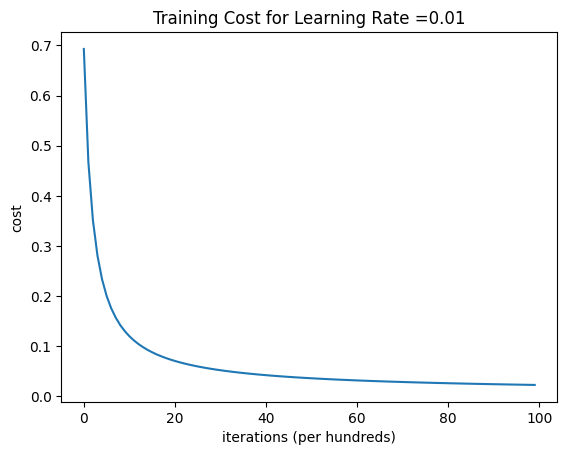

In [ ]:
# Plot learning curve (with costs)
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Training Cost for Learning Rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()


### 2.10 Choice of learning rate

**Reminder**:
In order for Gradient Descent to work you must choose the learning rate wisely $\left(\alpha \in (0,1)\right)$. The learning rate $\alpha$ determines how rapidly we update the parameters. If the learning rate is too large we may "overshoot" the optimal value. Similarly, if it is too small we will need too many iterations to converge to the best values. That's why it is crucial to use a well-tuned learning rate.
**Task**
- Run the training algorithm for 3 different learning rates [0.0001, 0.001, 0.5].
- Plot the Cost for each experiment on the same figure.
- Document your observations. (For example, what can you say about cost convergence for the smallest learning rate?)
- Select the best learning rate and explain why you made that selection.
- For the selected learning rate, would you change the number of iterations `num_iterations`? Why?


Training a model with learning rate: 0.0001


100%|██████████| 1000/1000 [00:09<00:00, 100.07it/s]


train accuracy: 99.43199920654297 %
test accuracy: 99.76399993896484 %

-------------------------------------------------------

Training a model with learning rate: 0.001


100%|██████████| 1000/1000 [00:10<00:00, 91.37it/s]


train accuracy: 99.62899780273438 %
test accuracy: 99.81099700927734 %

-------------------------------------------------------

Training a model with learning rate: 0.5


100%|██████████| 1000/1000 [00:12<00:00, 81.98it/s]


train accuracy: 99.89700317382812 %
test accuracy: 99.9530029296875 %

-------------------------------------------------------

Training a model with learning rate: 1


100%|██████████| 1000/1000 [00:11<00:00, 85.02it/s]


train accuracy: 99.92900085449219 %
test accuracy: 99.9530029296875 %

-------------------------------------------------------



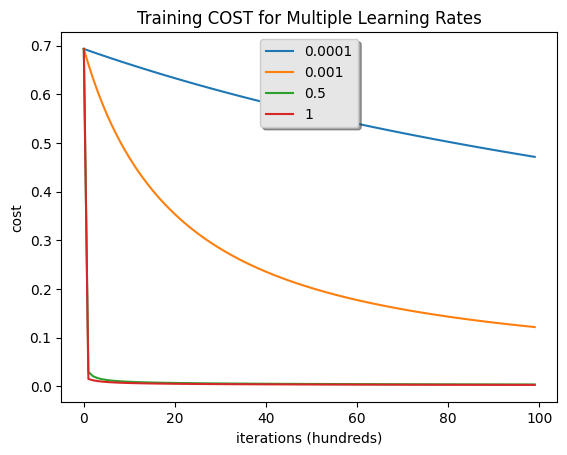

In [ ]:
learning_rates = [0.0001, 0.001, 0.5, 1]
models = {}

for lr in learning_rates:
    print ("Training a model with learning rate: " + str(lr))
    models[str(lr)] = train_model(train_X, train_Y, test_X, test_Y, num_iterations = 1000, learning_rate = lr, print_cost = False)
    print("train accuracy: {} %".format(models[str(lr)]["train_accuracy"]))
    print("test accuracy: {} %".format(models[str(lr)]["test_accuracy"]))
    print ('\n' + "-------------------------------------------------------" + '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')
plt.title("Training COST for Multiple Learning Rates")
legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

RESPONSE TO EXERCISE 2.10

`lr = 1e-4` The model convergence is slow, as expected, because the optimizer does not take long enough jump towards the right direction. The accuracy does not truely reflect how bad it is.

`lr = 1e-3` Here the model follow the expected convergence pattern, it reduces much steeper then it slows down, as if the optimizer rushed towards the gloabal optima, and once it is there, it slowly finds the point with zero slope.

`lr = 0.5` It shows a steep descent. In case of some more complex problem, the model will surely overshoot.

`lr = 1.0` Similar to `0.5`, there is a good chance that the model will overshoot.

Based on these observations, I think lr=0.001 is the best choice, as it converges without any possible overshoot, also I believe it generalizes well.

For this learning rate, `0.001`, I would change the number of iterations by 20% (by visual inspection.), as the model is still converging.

### 2.11 Try your one handwritten 0 or 1

**Tasks**
1. Handwrite a zero or one in a white page.
2. Take a picture of your number and crop the image with a squared layout.
3. Save the picture to the data folder in JPG format and with filename `my_image.jpg`. Same folder where the MNIST dataset is located.
4. Run the code below and document your observations.
5. Is the model predicting the right number?
    - Feel free to try different handwritten 1s and 0s at different illumination conditions.
    - Examine the original MNIST images.
        - Are there any differences between the MNIST images and your images?
        - What is the contrast between the number and the background?
            - HINT: `ImageEnhance.Contrast(factor)`. Try factor $\in (1.1, 1.9)$.
            - https://pillow.readthedocs.io/en/stable/reference/ImageEnhance.html
        - What is the pixel value of the background?
            - HINT: `ImageChops.invert()`
            - https://pillow.readthedocs.io/en/stable/reference/ImageChops.html
    - Do you need to update the code below to make your images better match the characteristics of the training data?
    - Update the code accordingly.
6. Make sure to try these steps with at least one 0 and one 1.
7. Document your observations and intuition.

y = tensor(1, dtype=torch.int32), your algorithm predicts a "1" picture.


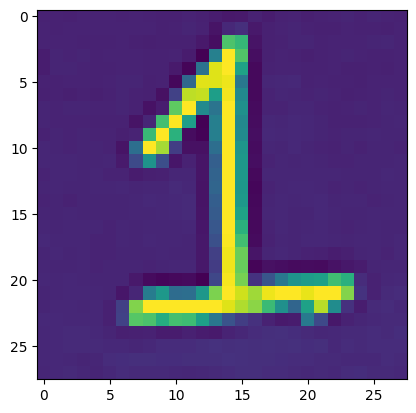

y = tensor(0, dtype=torch.int32), your algorithm predicts a "0" picture.


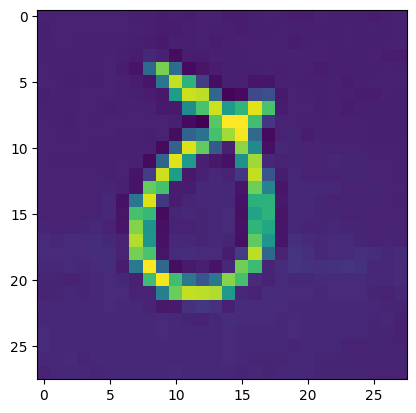

y = tensor(1, dtype=torch.int32), your algorithm predicts a "1" picture.


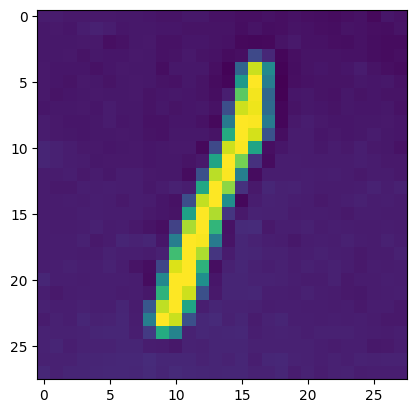

In [ ]:

#############################################
## YOUR CODE STARTS HERE
from PIL import Image
# change this to the name of your image file and data folder
my_image = [8319, 8320, 8322]
for img_id in my_image:
    fname = f'/content/mnist-in-csv/IMG_{img_id}.png'
    num_px = 28

    ## YOUR CODE ENDS HERE
    #############################################

    # Load and reshape the image to fit algorithm.
    image = Image.open(fname).convert('L').resize((num_px, num_px))


    # Do you need to manipulate your image to fit the training data?
    #############################################
    ## YOUR CODE STARTS HERE

    #image =
    #enhancer =
    #image = torch.tensor()

    ## YOUR CODE ENDS HERE
    #############################################


    # Preprocess the image to fit your algorithm.
    image = np.array(image)
    #Normalize
    image = image.astype(float) / 255.0

    # Enhance
    image = 1-image

    # Display image
    plt.imshow(image)

    # Flatten inputs
    image = image.reshape((1, num_px * num_px))

    # Attempt at categorizing image
    my_predicted_image = predict(logistic_regression_model["w"], logistic_regression_model["b"], torch.from_numpy(image).type(torch.float32))

    my_predicted_image = np.squeeze(my_predicted_image)

    classes = ['0', '1']
    print("y = " + str(my_predicted_image.type(torch.int))
        + ", your algorithm predicts a \"" + classes[int(my_predicted_image)] +  "\" picture.")
    plt.show()

#### RESPONSE TO Exercise 2.11

The model is pretty good at detecting the handwritten numbers. Although, I noticed without line number *36*, it was not able to get the correct output because, the data distribution was different (0's in place of the drawing and 1's everywhere else.).

It was a really great exercise to brush up the basics. - *Sounak*

# Congratulations you have completed your first homework!